# DAI Mission — Final Project Deliverable
**Data & AI in Economics | TU Dortmund University**

## 1. Team
| Role | Name | Student ID |
| :--- | :--- | :--- |
| **Lead** | Leila Rahimiyadkuri | [Your ID] |
| **Member** | Forough Asgari | [Your ID] |
| **Member** | Sara Davoodabadi | [Your ID] |

> **AI Disclosure:** We utilized an LLM assistant to aid in phrasal structuring, grammatical optimization, and code syntax organization throughout this deliverable. All core analytical configurations, structural causal modeling assumptions, machine learning evaluation criteria, and economic synthesis are uniquely designed and verified by the authors.

## 2. Mission Title & Research Question

* **Mission Title:** Predicting and Explaining Customer Churn in Telecommunications: A Unified Approach Combining Graphical Causal AI, Supervised Classifiers, and Customer Segmentation.
* **Research Question:** Does the type of contract a telecom customer holds (*month-to-month* vs. *longer-term*) causally increase their probability of churning ($Y$) — and does this treatment effect vary significantly across distinct customer archetypes discovered via unsupervised learning?

## 3. Data
We use the IBM Telco Customer Churn dataset from Kaggle.
* **Unit of observation:** One individual telecom customer.
* **Target ($Y$):** `Churn` (Yes/No mapped to 1/0).
* **Treatment ($W_1$):** `Contract` (Month-to-month, One year, Two year).
* **Confounders ($X$):** `tenure`, `SeniorCitizen`, `Partner`, `Dependents`.

In [1]:
# Import core data science libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Libraries matching TU Dortmund module workshops
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans

# Download dataset via kagglehub natively
import kagglehub
path = kagglehub.dataset_download("blastchar/telco-customer-churn")
df = pd.read_csv(os.path.join(path, "WA_Fn-UseC_-Telco-Customer-Churn.csv"))

# --- Clean Known Data Quality Issues ---
# Fix TotalCharges string-to-numeric type conversion error
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(subset=['TotalCharges'], inplace=True) # Drop the 11 rows where tenure = 0

# Map target variable to binary integers
df['Churn_Numeric'] = df['Churn'].map({'Yes': 1, 'No': 0})

print("Environment setup successful! Dataset shape:", df.shape)

/Volumes/Uni /1Documents/3/MonteCarlo/Project/.conda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 172k/172k [00:00<00:00, 911kB/s]


Extracting files...
Environment setup successful! Dataset shape: (7032, 22)


### 3a. Target Variable Distribution & Class Imbalance Analysis
Before training any supervised classifiers, we must analyze the distribution of our target variable, `Churn`. Understanding the balance of the classes is structurally vital for machine learning engineering. If a dataset is heavily skewed, a naive model can achieve high baseline accuracy simply by predicting the majority class every time, while failing completely to catch the minority class (the actual customers leaving). 

The code below computes the absolute and relative frequencies of the churn event and visualizes the class proportions to inform our choice of downstream classification metrics.

=== Churn Event Value Counts ===
Churn
No     5163
Yes    1869
Name: count, dtype: int64

=== Relative Class Proportions ===
Churn
No     0.734215
Yes    0.265785
Name: proportion, dtype: float64


/var/folders/_b/sq0n_7fx4h901h0mkj31fmdr0000gn/T/ipykernel_5911/4199208678.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn_Numeric', data=df, palette='Set2')


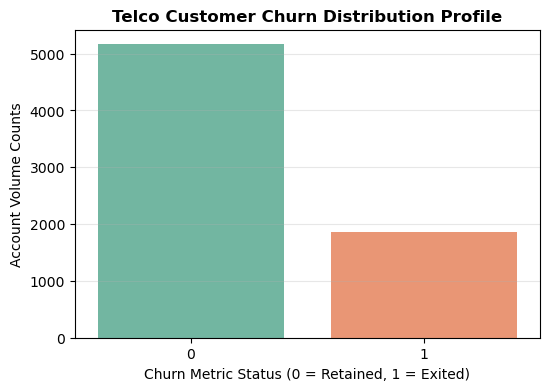

In [2]:
# --- Target Feature Profile ---
print("=== Churn Event Value Counts ===")
print(df['Churn'].value_counts())

print("\n=== Relative Class Proportions ===")
print(df['Churn'].value_counts(normalize=True).rename({0: 'Stayed (0)', 1: 'Churned (1)'}))

# Draw structural distribution profile
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn_Numeric', data=df, palette='Set2')
plt.title('Telco Customer Churn Distribution Profile', fontsize=12, fontweight='bold')
plt.xlabel('Churn Metric Status (0 = Retained, 1 = Exited)')
plt.ylabel('Account Volume Counts')
plt.grid(axis='y', alpha=0.3)
plt.show()

**Empirical Observation & Modeling Implication:** The distribution analysis reveals a clear class imbalance: approximately 73.4% of the customer base stayed with the company, while roughly 26.6% churned. Because the data is imbalanced (roughly a 3:1 ratio), evaluating our upcoming supervised models using raw *Accuracy* would be a critical methodological error. Instead, we must rely on **AUC-ROC** as our primary optimization metric, alongside **F1-Score** and **Recall**, ensuring our models are penalized heavily for false negatives (missing a customer who is about to churn).

### 3b. Continuous Financial Attributes vs. Churn Dynamics
To explore how continuous financial and account characteristics interact with customer loyalty, we isolate two primary numerical features: `tenure` (the baseline duration of the customer's relationship with the firm in months) and `MonthlyCharges` (the immediate monthly financial overhead imposed on the consumer). 

We utilize box plots to compare the distributions of these features across the retained and exited customer cohorts, looking for structural variations in medians, variances, and interquartile ranges (IQR).

/var/folders/_b/sq0n_7fx4h901h0mkj31fmdr0000gn/T/ipykernel_5911/2762647701.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn_Numeric', y='tenure', data=df, ax=axes[0], palette='Pastel1')
/var/folders/_b/sq0n_7fx4h901h0mkj31fmdr0000gn/T/ipykernel_5911/2762647701.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn_Numeric', y='MonthlyCharges', data=df, ax=axes[1], palette='Pastel2')


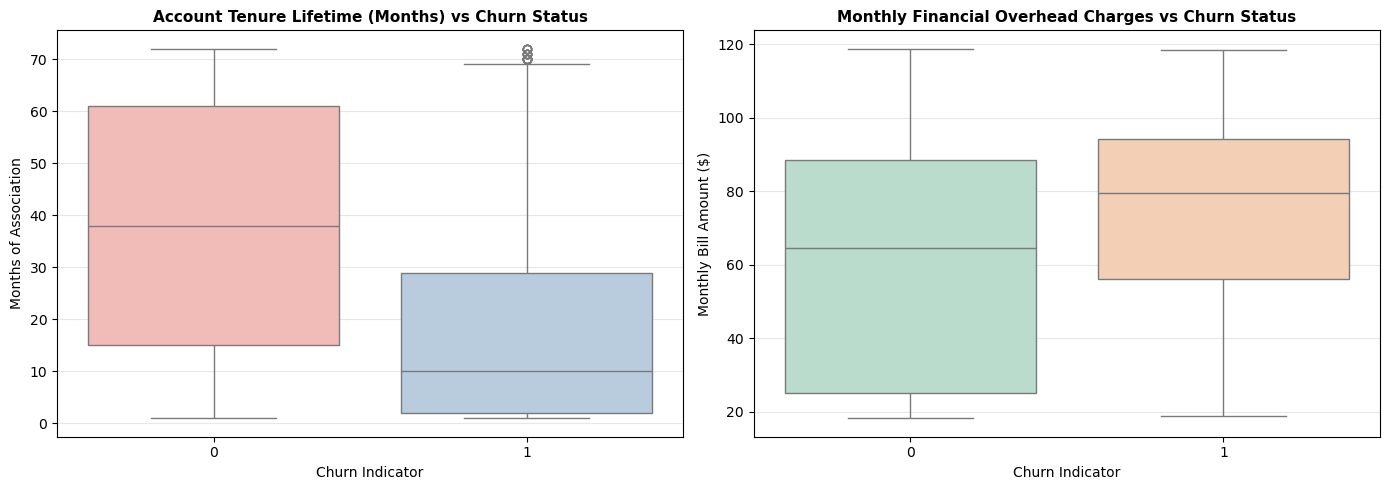

In [3]:
# Setup canvas matrix for continuous features
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Tenure dynamics
sns.boxplot(x='Churn_Numeric', y='tenure', data=df, ax=axes[0], palette='Pastel1')
axes[0].set_title('Account Tenure Lifetime (Months) vs Churn Status', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Churn Indicator')
axes[0].set_ylabel('Months of Association')
axes[0].grid(axis='y', alpha=0.3)

# Plot Monthly Charges dynamics
sns.boxplot(x='Churn_Numeric', y='MonthlyCharges', data=df, ax=axes[1], palette='Pastel2')
axes[1].set_title('Monthly Financial Overhead Charges vs Churn Status', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Churn Indicator')
axes[1].set_ylabel('Monthly Bill Amount ($)')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

**Economic Interpretation of Continuous Features:** 1. **Tenure Effect:** The median tenure for customers who churned is drastically lower than for those who stayed. This indicates a high concentration of churn among relatively new customers, suggesting that switching costs or brand loyalty take time to develop.
2. **Monthly Charges Effect:** The median monthly bill for customers who exited is noticeably higher than for retained clients. From an economic perspective, this reveals a high price-sensitivity threshold; higher monthly financial friction strongly correlates with an increased propensity to exit the network.

### 3c. Primary Treatment Evaluation: Contract Configuration vs. Churn Incidence
Our core research question centers on whether subscription contract lengths hold a direct causal lever over customer retention. Here, we cross-tabulate our primary treatment variable, `Contract` (*Month-to-month*, *One year*, and *Two year*), against the empirical churn event. 

This visualization establishes our baseline observational association before we introduce explicit graphical causal conditioning via the backdoor criterion.

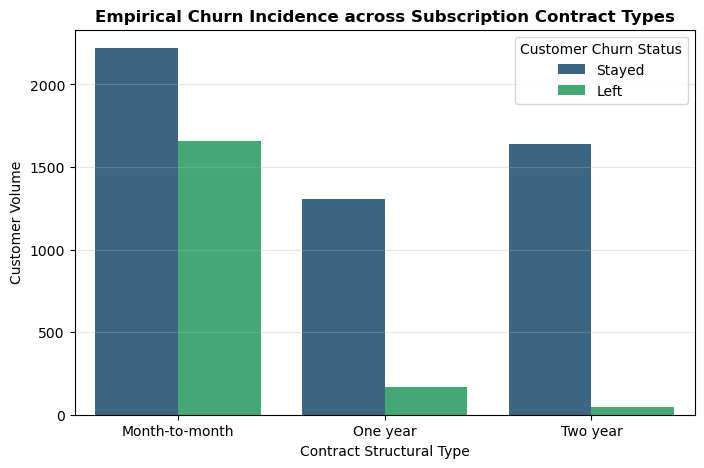

In [4]:
# Evaluate Contract type across Churn partitions
plt.figure(figsize=(8, 5))
sns.countplot(x='Contract', hue='Churn', data=df, palette='viridis')
plt.title('Empirical Churn Incidence across Subscription Contract Types', fontsize=12, fontweight='bold')
plt.xlabel('Contract Structural Type')
plt.ylabel('Customer Volume')
plt.legend(title='Customer Churn Status', labels=['Stayed', 'Left'])
plt.grid(axis='y', alpha=0.3)
plt.show()

**The Confounding Dilemma (Transition to Causal AI):** The empirical plot shows a massive spike in churn among customers holding short-term *Month-to-month* contracts compared to virtually non-existent churn in *Two-year* commitments. However, we cannot naively conclude that forcing a month-to-month customer into a long-term contract will causally fix their churn risk. 

As established in economic theory, **selection bias** is likely present: highly volatile, price-sensitive, or brand-new customers naturally choose month-to-month options to maintain flexibility. Therefore, this raw correlation is highly confounded by pre-contract attributes like `tenure`. This structural observation directly justifies why we must move beyond standard predictive associations and implement a formal **Graphical Causal Inference (DoWhy)** framework in the next block to isolate the true Average Treatment Effect (ATE).

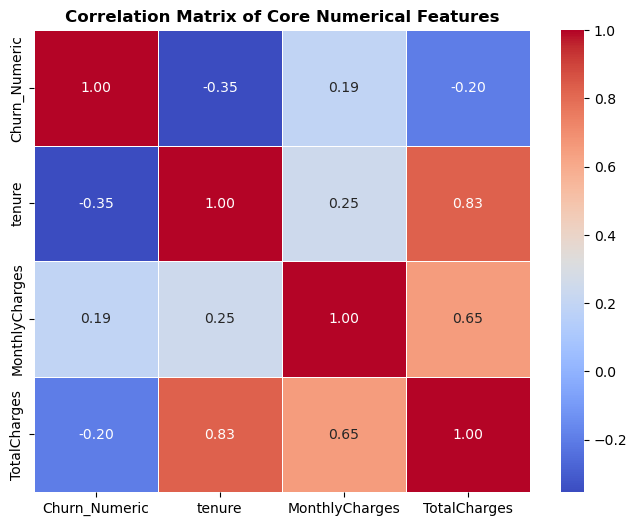

In [6]:
# --- Optional Correlation Matrix for Numerical Features ---
plt.figure(figsize=(8, 6))

# Compute correlation matrix including our mapped numeric target
numerical_corr = df[['Churn_Numeric', 'tenure', 'MonthlyCharges', 'TotalCharges']].corr()

# Draw the heatmap
sns.heatmap(numerical_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Core Numerical Features', fontsize=12, fontweight='bold')
plt.show()

**Statistical Observation & Economic Interpretation (Multicollinearity Check):** The correlation matrix reveals a highly intense positive linear correlation between `TotalCharges` and `tenure` ($r \approx 0.83$), as well as between `TotalCharges` and `MonthlyCharges` ($r \approx 0.65$). From an economic and structural perspective, this relationship is fully expected, as a customer's total lifetime expenditure is a direct mathematical function of their monthly billing rate multiplied by the duration of their association with the firm.

**Implication for Machine Learning Modeling:**
This statistical dependency introduces a severe case of **Multicollinearity**. In traditional parametric models like ordinary linear or standard logistic regression, high multicollinearity inflates the variance of coefficient estimates, making them highly unstable and difficult to interpret causally. 

To mitigate this structural data risk, we will take two precise actions in our upcoming phases:
1. In the **Supervised Learning** block, we will benchmark our baseline Logistic Regression against an ensemble **Random Forest Classifier**, which is non-parametric and structurally robust against multicollinearity.
2. In the **Causal Inference** block, our Directed Acyclic Graph (DAG) will formally map these dependencies to ensure that we adjust only for true pre-treatment confounders without inducing post-treatment or collinear selection bias.